In [1]:
# Example plots ADV data Hybrid Dune Campaign
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import xarray as xr

In [2]:
# Function to get NetCDF file path for ADVs
def get_nc_ADV(section, *args, processing_step='raw'):
    """
    Flexible function to get ADV NetCDF file path.
    Usage:
        get_nc_ADV('S3')
        get_nc_ADV('S3', 'ADV2')
        get_nc_ADV('S3', 'period 2')
        get_nc_ADV('S3', 'ADV2', 'period 2')
        get_nc_ADV('S3', processing_step='QC')
    """
    ADV = 'ADV1'
    period = 'period 1'
    # Parse positional arguments
    for arg in args:
        if str(arg).upper().startswith('ADV'):
            ADV = arg
        elif str(arg).lower().startswith('period'):
            period = arg

    if processing_step == 'raw':
        folder = r"O:\HybridDune experiment\data ADV, OBS\raw NetCDF"
        fname = f"ADV {section}{ADV} raw data - {period}.nc"
    elif processing_step == 'QC':
        folder = r"O:\HybridDune experiment\data ADV, OBS\QC"
        fname = f"ADV {section}{ADV} QC - {period}.nc"
    else:
        raise ValueError("processing_step must be 'raw' or 'QC'")

    fpath = os.path.join(folder, fname)
    if not os.path.exists(fpath):
        raise FileNotFoundError(f"File not found: {fpath}")
    return fpath

# Example usage:
# print(get_nc_ADV('S3'))
# print(get_nc_ADV('S3', 'ADV2'))
# print(get_nc_ADV('S3', 'period 2'))
# print(get_nc_ADV('S3', 'ADV2', 'period 2'))
# print(get_nc_ADV('S3', processing_step='QC'))



In [3]:
nc_QC  = get_nc_ADV('S3', 'ADV2', processing_step='QC')
with xr.open_dataset(nc_QC) as ds:
    ds_QC = ds.load()  # Loads all data into memory

ds_QC # print the variables in ds_processed

<xarray.Dataset> Size: 285MB
Dimensions:       (t: 414, N: 9573, t_theta: 3, t_zb: 4, t_zi: 2)
Coordinates:
  * t             (t) datetime64[ns] 3kB 2024-12-17T10:00:00 ... 2024-12-23T0...
  * N             (N) float64 77kB 0.0 0.125 0.25 ... 1.196e+03 1.196e+03
  * t_theta       (t_theta) datetime64[ns] 24B 2024-12-17T10:00:00 ... 2024-1...
  * t_zb          (t_zb) datetime64[ns] 32B 2024-12-17T11:30:00 ... 2024-12-2...
  * t_zi          (t_zi) datetime64[ns] 16B 2024-12-17T11:30:00 2024-12-21T14...
    maskp         (t, N) bool 4MB False False False False ... True True True
    maskv         (t, N) bool 4MB False False False False ... True True True
    maskd         (t, N) bool 4MB False False False False ... True True True
    mask_OBShigh  (t, N) bool 4MB True True True True ... True True True True
    mask_OBSlow   (t, N) bool 4MB True True True True ... True True True True
Data variables: (12/43)
    sf            float64 8B 8.0
    u             (t, N) float64 32MB nan nan nan nan ... -0.095 -0.177 -0.212
    v             (t, N) float64 32MB nan nan nan nan ... 0.106 0.154 0.183
    w             (t, N) float64 32MB nan nan nan nan ... -0.036 -0.051 -0.073
    burst         (t, N) float64 32MB 98.0 98.0 98.0 98.0 ... 235.0 235.0 235.0
    pm            (t) float64 3kB 0.0 0.4252 1.141 ... 9.779e+03 9.881e+03
    ...            ...
    pc            (t, N) float64 32MB nan nan nan ... 9.191e+03 9.011e+03
    eta           (t, N) float64 32MB nan nan nan nan ... 0.783 0.754 0.736
    zsmean        (t) float64 3kB nan -0.2037 -0.2196 nan ... 1.004 1.084 1.09
    h             (t) float64 3kB nan 0.7853 0.7694 nan ... 1.613 1.691 1.696
    C_OBShigh     (t, N) float64 32MB nan nan nan nan nan ... 1.74 1.7 2.3 4.62
    C_OBSlow      (t, N) float64 32MB nan nan nan nan ... 2.68 2.72 2.74 3.12
Attributes: (12/14)
    Conventions:               CF-1.6
    title:                     S3ADV2 raw data - period 1
    instrument:                Nortek Vector
    instrument serial number:  VEC13933
    connected OBS type:        Seapoint STM
    time zone:                 UTC+1
    ...                        ...
    contact person:            Daan Poppema
    emailadres:                d.w.poppema@tudelft.nl
    construction datetime:     20-Oct-2025 (18:24:23)
    version:                   v2
    version comments:          constructed with xarray
    comment:                   Quality checked data: pressure level corrected...

In [6]:
nc_QC

'O:\\HybridDune experiment\\data ADV, OBS\\QC\\ADV S3ADV1 QC - period 2.nc'

In [4]:
# LOAD DATA FOR PLOTTING WATERLEVEL TIMESERIES
# PRESSURE SENSOR: S3.BS3 ----------------------------------------------------------------------
nc_path = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\processed\Deployment period 1\Pressure sensor S3 P_BS3 (RBR) processed data - period 1.nc'
with xr.open_dataset(nc_path) as ds:
    t_full = ds.t_full.values
    zs_rolling = ds.zs.rolling(t_full=16*60*10, center=True).mean()
    
    # subset: only every 600th value of t_full and zs_rolling for plotting speed
    t_full = t_full[::16*60]
    zs_rolling = zs_rolling.values[::16*60]

    t_block = ds.t_block.values
    Hm0 = ds.Hm0.values
    Hm0_IG = ds.Hm0_IG.values
    Hm0_WW = ds.Hm0_WW.values

    Tp = ds.Tp.values
    Tm = ds.Tm01.values

nc_path = r'O:\HybridDune experiment\data RBR, OSSI\netcdf\processed\Deployment period 2\Pressure sensor S3 P_BS3 (RBR) processed data - period 2.nc'
with xr.open_dataset(nc_path) as ds:
    t_full_b = ds.t_full.values
    zs_rolling_b = ds.zs.rolling(t_full=16*60*10, center=True).mean()
    
    # subset: only every 600th value of t_full and zs_rolling for plotting speed
    t_full_b = t_full_b[::16*60]
    zs_rolling_b = zs_rolling_b.values[::16*60]

    t_block_b = ds.t_block.values
    Hm0_b = ds.Hm0.values
    Hm0_IG_b = ds.Hm0_IG.values
    Hm0_WW_b = ds.Hm0_WW.values

    Tp_b = ds.Tp.values
    Tm_b = ds.Tm01.values

<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\s'
C:\Users\dpoppema\AppData\Local\Temp\ipykernel_7244\1024793541.py:37: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(ds_QC.t, nans_dp, linewidth=line_width,   label='|dp|<4$\sigma$')
C:\Users\dpoppema\AppData\Local\Temp\ipykernel_7244\1024793541.py:39: SyntaxWarning: invalid escape sequence '\s'
  ax.plot(ds_QC.t, nans_du, linewidth=line_width,   label='|du,v,w| < 3$\sigma$')


0
1
2
3
4
6


C:\Users\dpoppema\AppData\Local\Temp\ipykernel_7244\1024793541.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


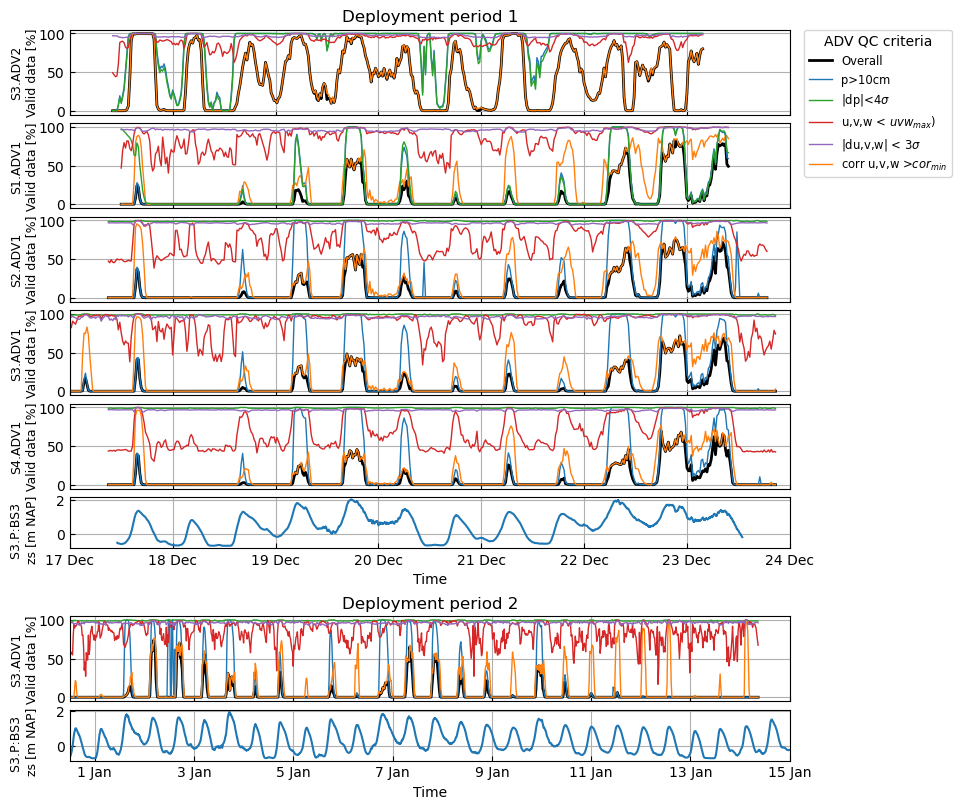

In [5]:
fig = plt.figure(figsize=(8, 8.5))
ax_x0 = 0.1
ax_w = 0.9
ax_y0 = [0.87, 0.76, 0.65, 0.54, 0.43, 0.36, 0.18, 0.11]
ax_h =  [0.1,  0.1,  0.1,  0.1,  0.1, 0.06,  0.1,  0.06]
axes = []

line_width=1
sections = ['S3',       'S1',     'S2',      'S3',      'S4',      'xx','S3'      ]
ADV =      ['ADV2',    'ADV1',    'ADV1',    'ADV1',    'ADV1',    'xx','ADV1'    ]
period =   ['period 1','period 1','period 1','period 1','period 1','xx','period 2']

# make axes for subplots
axes.append(fig.add_axes([ax_x0, ax_y0[0], ax_w, ax_h[0]]))
for i in range(1,8):
    axes.append(fig.add_axes([ax_x0, ax_y0[i], ax_w, ax_h[i]])) # Next 5 axes share x with the first

for i in [0,1,2,3,4,6]:
    print(i)
    nc_QC  = get_nc_ADV(sections[i], ADV[i],period[i], processing_step='QC')
    with xr.open_dataset(nc_QC) as  ds_QC:

        # Plot the avg relative pressure and the fraction of nans in the data
        frac_nans = ds_QC['u'].isnull().sum(axis=1) / ds_QC.sizes['N']
        perc_valid = 100 * (1 - frac_nans)  # convert to percentage of valid data

        nans_dp  = 100* ds_QC['maskp'].mean(axis=1)  # |dp| < 4sigma
        nans_dry = 100* ds_QC['maskd'].mean(axis=1)  # p < 10cm
        nans_u   = 100* ds_QC['mu'].mean(axis=1)  # |dp| < 4sigma
        nans_du  = 100* ds_QC['md'].mean(axis=1)   # |dp| < 4sigma
        nans_cor = 100* ds_QC['mc'].mean(axis=1)  # |dp| < 4sigma
    
    ax = axes[i]
    ax.plot(ds_QC.t, perc_valid, linewidth=2, color='black', label='Overall')
    ax.plot(ds_QC.t, nans_dry, linewidth=line_width,  label='p>10cm')
    ax.plot(ds_QC.t, nans_cor, linewidth=line_width,  label='corr u,v,w >$cor_{min}$')
    ax.plot(ds_QC.t, nans_dp, linewidth=line_width,   label='|dp|<4$\sigma$')
    ax.plot(ds_QC.t, nans_u, linewidth=line_width,    label='u,v,w < $uvw_{max}$)')
    ax.plot(ds_QC.t, nans_du, linewidth=line_width,   label='|du,v,w| < 3$\sigma$')

    # set legend, legend order
    handles, labels = ax.get_legend_handles_labels()
    order = [0, 1, 3, 4, 5, 2]  # Specify the desired order by index (e.g., [2, 0, 1, 4, 3, 5])
    if i == 0:
        ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order], title='ADV QC criteria',
                  loc='upper left', bbox_to_anchor=(1.02, 1), fontsize='small', borderaxespad=0, frameon=True)
        # ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order])

    adv_name = f'{sections[i]}.{ADV[i]}'
    ax.set_ylabel(adv_name+'\nValid data [%]', fontsize=9, labelpad=0)
    ax.grid()
    ax.tick_params(axis='x', direction='in')
    ax.tick_params(axis='y', direction='in')
    
# Plot water level
ax = axes[5]
ax.plot(t_full, zs_rolling)
ax.set_ylabel('S3.P:BS3    \n zs [m NAP]    ', fontsize=9, labelpad=13)

ax.grid()
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')

ax = axes[7]
ax.plot(t_full_b, zs_rolling_b)
ax.set_ylabel('S3.P:BS3    \n zs [m NAP]    ', fontsize=9, labelpad=13)
ax.grid()
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='y', direction='in')

# Set axes, xticks
axes[0].set_title('Deployment period 1')
axes[5].set_xlabel('Time')
axes[6].set_title('Deployment period 2')
axes[7].set_xlabel('Time')

for i, ax in enumerate(axes):
    date_fmt = mdates.DateFormatter('%#d %b')
    ax.xaxis.set_major_formatter(date_fmt)
    if i < 6:
        ax.set_xlim([pd.Timestamp('2024-12-17'), pd.Timestamp('2024-12-24')])
    else:
        ax.set_xlim([pd.Timestamp('2024-12-31T12:00'), pd.Timestamp('2025-01-15')])
    if i < 5 or i==6:
        ax.set_xticklabels([], visible=False)
plt.tight_layout()
fig.autofmt_xdate() 

plt.show()

# save figure
fig_path = r'O:\HybridDune experiment\temp figures paper\ADV_QC_timeseries'
#fig.savefig(fig_path+'.png', dpi=300, bbox_inches='tight')
#fig.savefig(fig_path+'.pdf', bbox_inches='tight')